In [ ]:
# Análisis de Casos de Violencia en Perú (2016 - 2024)

Este notebook presenta un análisis exploratorio de los casos de violencia familiar y sexual reportados en Perú, utilizando datos oficiales. Se exploran tendencias anuales, distribución por departamentos y se identifican posibles valores atípicos.

## 1. Carga y limpieza de datos

Se realiza la carga del archivo de datos y se limpia para dejarlo listo para el análisis:

In [1]:
## se importan las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
## se carga el archivo y se coloca en  latin1 para la codificacion de caracteres
df = pd.read_csv('2.5.1_BdD_SAU_8.csv', sep=';', encoding='latin1', dtype=str)

# Eliminar columnas vacías
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [3]:
#se evaluan el tipo de datos que tiene cada columna y si existen valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 41 columns):
 #   Column                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                  --------------  ----- 
 0   AÑO DEL REPORTE DE INFORMACION                                                                          55 non-null     object
 1   PERIODO DE LA INFORMACION REMITIDA                                                                      55 non-null     object
 2   FECHA DE REPORTE DE LA INFORMACIÓN                                                                      55 non-null     object
 3   CODIGO DE LA ENTIDAD (ENT001)                                                                           55 non-null     object
 4   PROGRAMA NACIONAL CONTRA LA VIOLENCIA FAMILIAR Y SEXUAL                                             

In [4]:
#se ve que datos tiene cada columna
df.head(3)

,AÑO DEL REPORTE DE INFORMACION,PERIODO DE LA INFORMACION REMITIDA,FECHA DE REPORTE DE LA INFORMACIÓN,CODIGO DE LA ENTIDAD (ENT001),PROGRAMA NACIONAL CONTRA LA VIOLENCIA FAMILIAR Y SEXUAL,CODIGO DE LA LINEA DE INTERVENCION (LIN001),NOMBRE DE LA LINEA DE INTERVENCIÓN (ATENCIÓN INTEGRAL Y MULTIDISCIPLINARIA PARA VICTIMAS DE VIOLENCIA),CODIGO DEL SERVICIO,NOMBRE DEL SERVICIO (SERVICIO DE ATENCIÓN URGENTE),UBIGEO DE LA UBICACIÓN GEOGRÁFICA DEL LUGAR DE RESIDENCIA DE LA USUARIA - SEGÚN EL INEI,...,N° CASOS ATENDIDOS - 15_17 - MUJERES,N° CASOS ATENDIDOS - 18_29 - TOTAL,N° CASOS ATENDIDOS - 18_29 - HOMBRES,N° CASOS ATENDIDOS - 18_29 - MUJERES,N° CASOS ATENDIDOS - 30_59 - TOTAL,N° CASOS ATENDIDOS - 30_59 - HOMBRES,N° CASOS ATENDIDOS - 30_59 - MUJERES,N° CASOS ATENDIDOS - 60_MÁS- TOTAL,N° CASOS ATENDIDOS - 60_MÁS - HOMBRES,N° CASOS ATENDIDOS - 60_MÁS - MUJERES
0,2016,ENE - DIC,31/12/2016,ENT001,PROGRAMA NACIONAL CONTRA LA VIOLENCIA FAMILIAR...,LN001,ATENCIÓN INTEGRAL Y MULTIDISCIPLINARIA PARA VI...,SER003,SERVICIO DE ATENCIÓN URGENTE,150101,...,315,364,18,346,338,19,319,168,31,137
1,2017,ENE - DIC,31/12/2017,ENT001,PROGRAMA NACIONAL CONTRA LA VIOLENCIA FAMILIAR...,LIN001,ATENCIÓN INTEGRAL Y MULTIDISCIPLINARIA PARA VI...,SER003,SERVICIO DE ATENCIÓN URGENTE,150101,...,299,406,9,397,406,5,401,107,38,69
2,2017,ENE - DIC,31/12/2017,ENT001,PROGRAMA NACIONAL CONTRA LA VIOLENCIA FAMILIAR...,LIN001,ATENCIÓN INTEGRAL Y MULTIDISCIPLINARIA PARA VI...,SER003,SERVICIO DE ATENCIÓN URGENTE,040101,...,1,6,0,6,0,0,0,0,0,0


In [8]:
# Convertir la columna del año a entero
df["AÑO DEL REPORTE DE INFORMACION"] = pd.to_numeric(df["AÑO DEL REPORTE DE INFORMACION"], errors='coerce').astype("Int64")

# Convertir la columna de fecha a tipo datetime
df["FECHA DE REPORTE DE LA INFORMACIÓN"] = pd.to_datetime(df["FECHA DE REPORTE DE LA INFORMACIÓN"], errors='coerce', dayfirst=True)


In [9]:
# se cambian el tipo de datos a int de las columanas que deberian ser numericas
columnas_numericas = df.columns[17:41].tolist()
df[columnas_numericas] = df[columnas_numericas].replace(',', '', regex=True)
df[columnas_numericas] = df[columnas_numericas].apply(pd.to_numeric, errors='coerce')

RESUMEN ESTADISTICO

In [11]:
print(df.describe())


       AÑO DEL REPORTE DE INFORMACION FECHA DE REPORTE DE LA INFORMACIÓN  \
count                            55.0                                 55   
mean                      2020.963636      2021-12-21 16:08:43.636363520   
min                            2016.0                2016-12-31 00:00:00   
25%                            2019.0                2020-01-14 00:00:00   
50%                            2021.0                2022-01-15 00:00:00   
75%                            2023.0                2024-01-15 00:00:00   
max                            2024.0                2024-11-15 00:00:00   
std                          2.159935                                NaN   

       N° CASOS ATENDIDOS -TOTAL  N° CASOS ATENDIDOS - HOMBRES - TOTAL  \
count                  55.000000                             55.000000   
mean                  979.127273                            249.400000   
min                     0.000000                              0.000000   
25%                

In [14]:
# Definimos las columnas numéricas
columnas_numericas = df.columns[17:41]

# Recorremos cada columna para aplicar la detección de outliers
for columna in columnas_numericas:
    # Saltar si la columna tiene todos sus valores nulos
    if df[columna].dropna().empty:
        continue

    # Calcular Q1, Q3 e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar valores atípicos
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    # Imprimir resultados si se encontraron outliers
    if not outliers.empty:
        print(f"\n📊 Outliers en '{columna}':")
        print(outliers[["AÑO DEL REPORTE DE INFORMACION", "DEPARTAMENTO", columna]])
        print(f"Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
        print("-" * 60)


📊 Outliers en 'N° CASOS ATENDIDOS -TOTAL':
    AÑO DEL REPORTE DE INFORMACION        DEPARTAMENTO  \
0                             2016  LIMA METROPOLITANA   
1                             2017  LIMA METROPOLITANA   
5                             2018  LIMA METROPOLITANA   
7                             2019                LIMA   
20                            2020                LIMA   
23                            2021                LIMA   
31                            2022                LIMA   
39                            2023                LIMA   
47                            2024                LIMA   

    N° CASOS ATENDIDOS -TOTAL  
0                        4414  
1                        4030  
5                        4653  
7                        4594  
20                       2840  
23                       2677  
31                       2498  
39                       2836  
47                       2373  
Límites: [-294.25, 1551.75]
---------------------------

Al analizar los outliers se entiende que todos ellos provienen del departamento de lima y lima metropolitana, cabe aclarar que bajo el contexto de este dataset ambos departamentos son tratados de igual manerasolo que el nombre cambio a lo largo de los años. Ademas se hara un enfoque en los casos totales en vez de verlo por cada edad

PRUEBA CON CASOS TOTALES

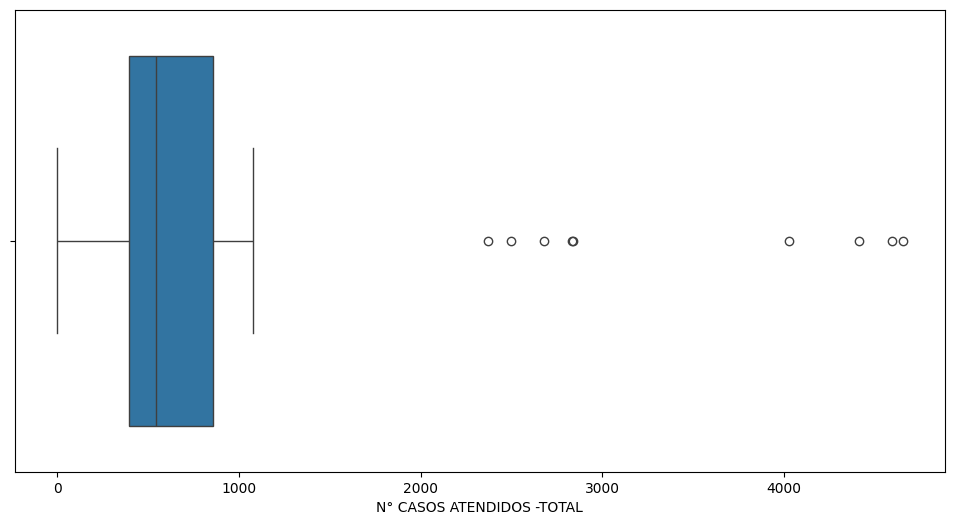

In [10]:
#se realiza una evaluacion a los casos totales
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x=df["N° CASOS ATENDIDOS -TOTAL"])
plt.show()


Existe alrededor de 8 valores atipicos, en donde todos pertenecen a Lima, lo cual podría explicarse por su alta densidad poblacional y mayor acceso a servicios de reporte. Ahora, aunque estadisticamente son valores atipicos,  no necesariamente representan un error por las razones antes mencionadas.

In [17]:
Q1 = df["N° CASOS ATENDIDOS -TOTAL"].quantile(0.25)  # Percentil 25%
Q3 = df["N° CASOS ATENDIDOS -TOTAL"].quantile(0.75)  # Percentil 75%
IQR = Q3 - Q1  # Rango intercuartílico

# Valores atípicos (definición estándar: menor que Q1 - 1.5*IQR o mayor que Q3 + 1.5*IQR)
outliers = df[(df["N° CASOS ATENDIDOS -TOTAL"] < Q1 - 1.5*IQR) |
              (df["N° CASOS ATENDIDOS -TOTAL"] > Q3 + 1.5*IQR)]

outliers_vista = outliers[["AÑO DEL REPORTE DE INFORMACION", "N° CASOS ATENDIDOS -TOTAL", "DEPARTAMENTO"]].rename(
    columns={"AÑO DEL REPORTE DE INFORMACION": "AÑO"}
)

print(outliers_vista)


     AÑO  N° CASOS ATENDIDOS -TOTAL        DEPARTAMENTO
0   2016                       4414  LIMA METROPOLITANA
1   2017                       4030  LIMA METROPOLITANA
5   2018                       4653  LIMA METROPOLITANA
7   2019                       4594                LIMA
20  2020                       2840                LIMA
23  2021                       2677                LIMA
31  2022                       2498                LIMA
39  2023                       2836                LIMA
47  2024                       2373                LIMA


COMPARACION POR DEPARTAMENTOS

In [ ]:
df.groupby("DEPARTAMENTO")["N° CASOS ATENDIDOS -TOTAL"].sum().sort_values(ascending=False)

,N° CASOS ATENDIDOS -TOTAL
DEPARTAMENTO,
LIMA,17818
LIMA METROPOLITANA,13097
AREQUIPA,5290
HUANUCO,3970
LA LIBERTAD,3929
CUSCO,2639
AYACUCHO,2629
PUNO,2248
MADRE DE DIOS,2232


<ipython-input-20-c41b25746426>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


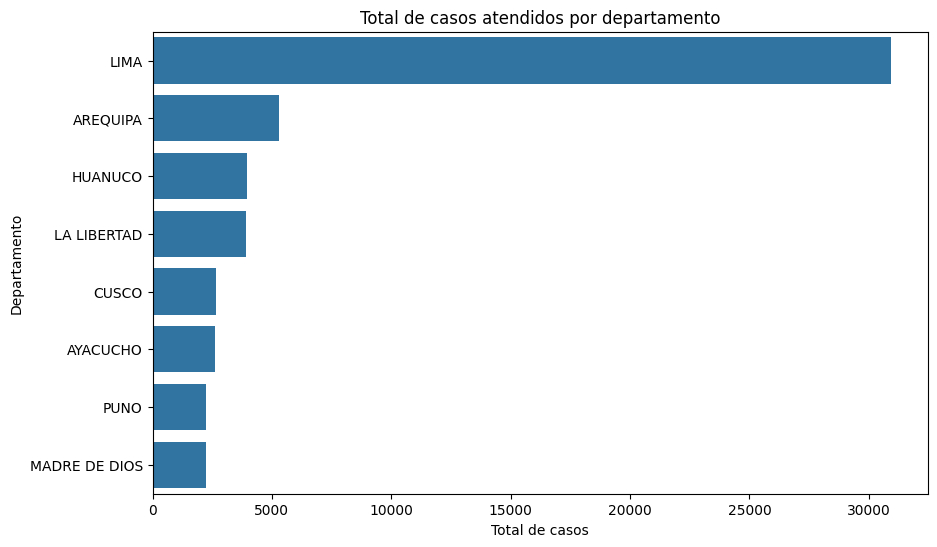

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import groupby
df['DEPARTAMENTO_UNIFICADO']=df['DEPARTAMENTO'].replace({"LIMA METROPOLITANA":"LIMA"})

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="N° CASOS ATENDIDOS -TOTAL",
    y="DEPARTAMENTO_UNIFICADO",
    estimator=sum,
    ci=None,
    order=df.groupby("DEPARTAMENTO_UNIFICADO")["N° CASOS ATENDIDOS -TOTAL"].sum().sort_values(ascending=False).index,
)
plt.title("Total de casos atendidos por departamento")
plt.xlabel("Total de casos")
plt.ylabel("Departamento")
plt.tight_layout
plt.show()

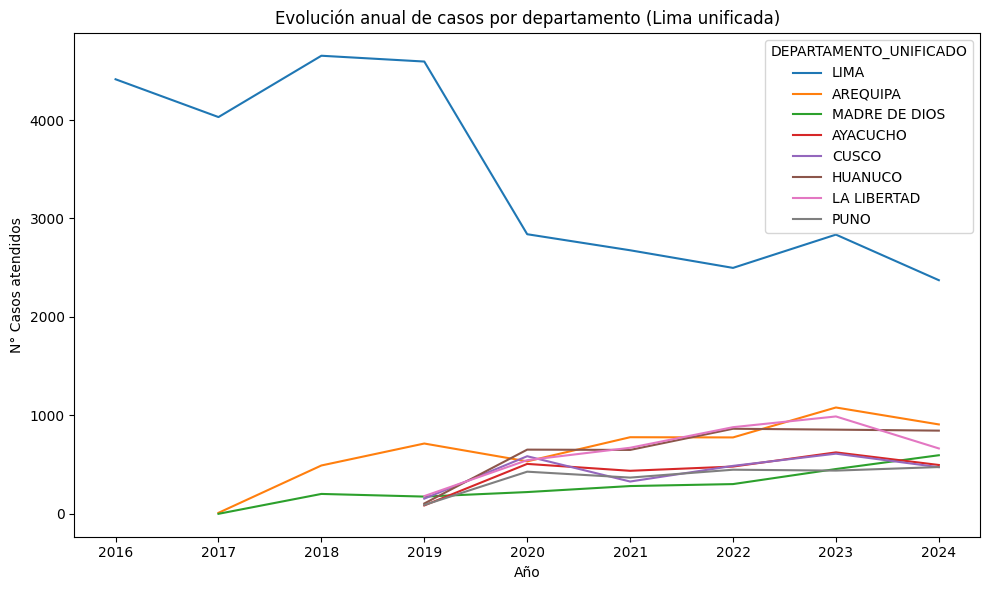

In [ ]:
df_grouped=df.groupby(["AÑO DEL REPORTE DE INFORMACION", "DEPARTAMENTO_UNIFICADO"])["N° CASOS ATENDIDOS -TOTAL"].sum().reset_index()
#grafica de lineas


plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_grouped,
    x="AÑO DEL REPORTE DE INFORMACION",
    y="N° CASOS ATENDIDOS -TOTAL",
    hue="DEPARTAMENTO_UNIFICADO"
)
plt.title("Evolución anual de casos por departamento (Lima unificada)")
plt.ylabel("N° Casos atendidos")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

In [ ]:
total_lima = df[df["DEPARTAMENTO"].isin(["LIMA", "LIMA METROPOLITANA"])]["N° CASOS ATENDIDOS -TOTAL"].sum()
total_nacional = df["N° CASOS ATENDIDOS -TOTAL"].sum()

porcentaje = (total_lima / total_nacional) * 100
print(f"Lima (incluyendo Lima Metropolitana) representa el {porcentaje:.2f}% del total nacional de casos atendidos.")


Lima (incluyendo Lima Metropolitana) representa el 57.41% del total nacional de casos atendidos.
